<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

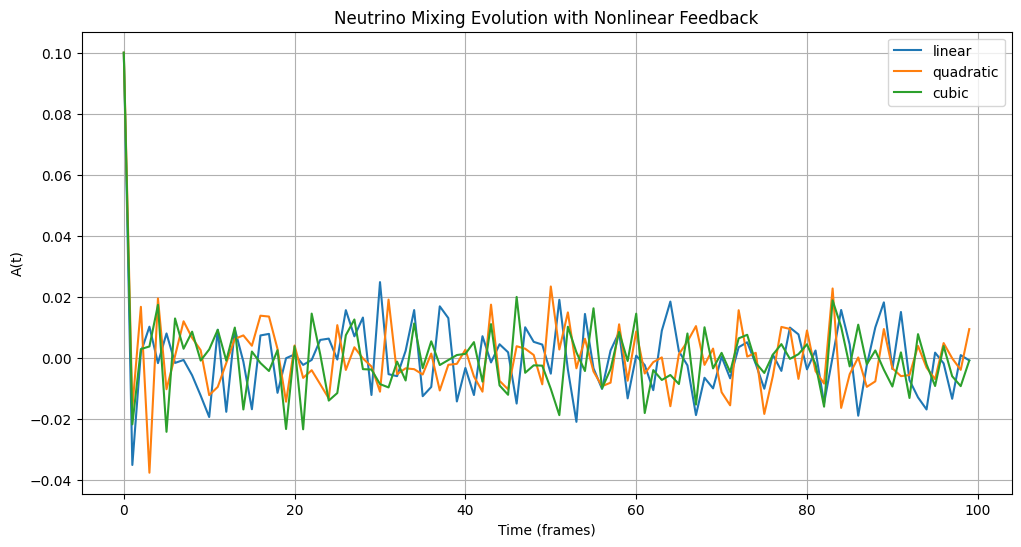

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Evolution Equation Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma_0 = 0.5
epsilon = 0.01  # Nonlinear cubic term
xi = 0.01
A0 = 0.1
frames = 100

# -------------------------------
# Evolution Function
# -------------------------------
def evolve_A(model='cubic'):
    A = [A0]
    for t in range(1, frames):
        prev = A[-1]
        laplacian = 0  # Placeholder for spatial term
        noise = xi * np.random.randn()
        if model == 'linear':
            next_A = -kappa * prev + gamma_0 * laplacian + noise
        elif model == 'quadratic':
            next_A = -kappa * prev + delta * prev**2 + gamma_0 * laplacian + noise
        elif model == 'cubic':
            next_A = -kappa * prev + delta * prev**2 + epsilon * prev**3 + gamma_0 * laplacian + noise
        A.append(next_A)
    return A

# -------------------------------
# Run and Plot
# -------------------------------
models = ['linear', 'quadratic', 'cubic']
results = {m: evolve_A(m) for m in models}

plt.figure(figsize=(12, 6))
for m in models:
    plt.plot(results[m], label=m)
plt.title("Neutrino Mixing Evolution with Nonlinear Feedback")
plt.xlabel("Time (frames)")
plt.ylabel("A(t)")
plt.legend()
plt.grid(True)
plt.show()
